In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_wb.csv')
df2 = pd.read_csv('pdp_KINN_28_wb.csv')
df3 = pd.read_csv('pdp_KINN_56_wb.csv')
odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['wb', 'fc']
df2.columns = ['wb', 'fc']
df3.columns = ['wb', 'fc']
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]

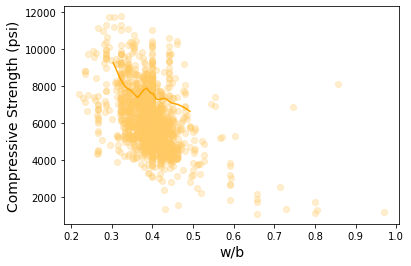

In [2]:
# Plot the results
plt.figure()
# plt.plot(df1['wb'],df1['fc'], label='7',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 1,color = '#63b2ee')
plt.plot(df2['wb'], df2['fc']*145.0377, label='28', color = 'orange')
plt.scatter(odf2['w/b'],odf2['fc (MPa)']*145.0377, alpha = 0.3,color='#FFCA64')
# plt.plot(df3['wb'], df3['fc']*145.0377, label='56', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)']*145.0377, alpha = 0.5,color='#90EE90')
plt.ylabel('Compressive Strength (psi)',fontsize=14)
plt.xlabel('w/b',fontsize=14)
# plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
# plt.xlim(0.2,0.6)

# plt.legend()

plt.savefig('KINN vs distribution.png', bbox_inches='tight',dpi=600)

/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:29: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:29: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:29: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.


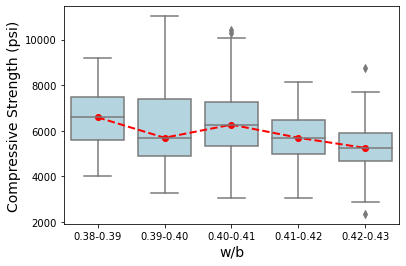

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the file
file_path = 'updated_fc_predictions_with_fc_hat.xlsx'  # Replace with the actual file path
df = pd.read_excel(file_path, sheet_name='28')

# Convert fc (MPa) to psi
df['fc_psi'] = df['fc (MPa)'] * 145.0377

# Define new bins for the w/b ranges you want (only 0.38 to 0.43)
bins_filtered = [0.38, 0.39, 0.40, 0.41, 0.42, 0.43]
labels_filtered = ['0.38-0.39', '0.39-0.40', '0.40-0.41', '0.41-0.42', '0.42-0.43']

# Add a new column to classify 'w/b' into the filtered bins for sheet 28
df['w/b_bin'] = pd.cut(df['w/b'], bins=bins_filtered, labels=labels_filtered, right=False)

# Calculate the median fc_psi for each w/b bin (rather than average)
median_fc_psi_filtered = df.groupby('w/b_bin')['fc_psi'].median()

plt.figure()
sns.boxplot(x='w/b_bin', y='fc_psi', data=df, color='lightblue')
plt.xlabel('w/b', fontsize=14)
plt.ylabel('Compressive Strength (psi)', fontsize=14)

# Plot the trend line by connecting the median values
plt.plot(median_fc_psi_filtered.index, median_fc_psi_filtered.values, marker='o', color='r', linestyle='--', linewidth=2, label='Median Trend')


plt.xticks(rotation=0)  # Rotate the x-axis labels for better readability

# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('KINN boxplot.png', bbox_inches='tight',dpi=600)


/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:31: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:31: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
/Users/zhangtianjie/opt/anaconda3/envs/t

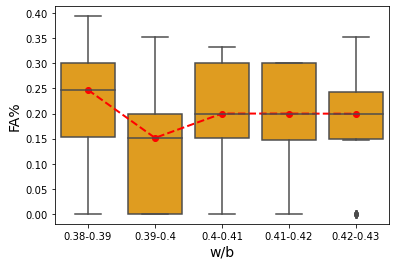

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the file
file_path = 'updated_fc_predictions_with_fc_hat.xlsx'  # Replace with the actual file path
df = pd.read_excel(file_path, sheet_name='28')
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data based on the specified w/b ranges
wb_ranges = [(0.38, 0.39), (0.39, 0.40), (0.40, 0.41), (0.41, 0.42), (0.42, 0.43)]
df_filtered = pd.DataFrame()

for lower, upper in wb_ranges:
    df_temp = df[(df['w/b'] >= lower) & (df['w/b'] < upper)]
    df_temp['w/b range'] = f"{lower}-{upper}"
    df_filtered = pd.concat([df_filtered, df_temp])

# Create the boxplot for SCM%
plt.figure()
sns.boxplot(x='w/b range', y='FA%', data=df_filtered, color='orange')


# Calculate the median values for each w/b range
median_values = df_filtered.groupby('w/b range')['FA%'].median()


# Plot the trend line based on the median values
plt.plot(median_values.index, median_values.values, color='red', marker='o', linestyle='--', linewidth=2)

plt.xlabel('w/b', fontsize=14)
plt.ylabel('FA%', fontsize=14)

plt.savefig('FA% boxplot.png', dpi=600)

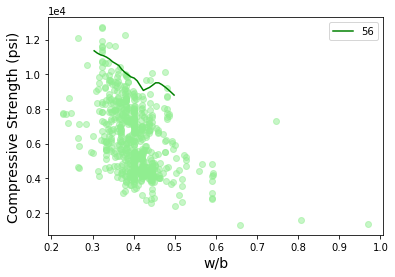

In [5]:
# Plot the results
plt.figure()
# plt.plot(df1['wb'],df1['fc'], label='7',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 1,color = '#63b2ee')
# plt.plot(df2['wb'], df2['fc']*145.0377, label='28', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)']*145.0377, alpha = 0.5,color='#FFCA64')
plt.plot(df3['wb'], df3['fc']*145.0377, label='56', color = 'green')
plt.scatter(odf3['w/b'],odf3['fc (MPa)']*145.0377, alpha = 0.5,color='#90EE90')
plt.ylabel('Compressive Strength (psi)',fontsize=14)
plt.xlabel('w/b',fontsize=14)
plt.legend()
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.legend()

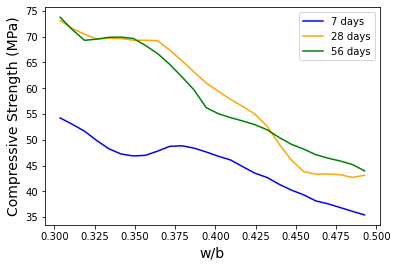

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_wb_7.csv')
df2 = pd.read_csv('pdp_KINN_wb_28.csv')
df3 = pd.read_csv('pdp_KINN_wb_56.csv')
odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['wb', 'fc']
df2.columns = ['wb', 'fc']
df3.columns = ['wb', 'fc']
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]

# Plot the results
plt.figure()
plt.plot(df1['wb'],df1['fc'], label='7 days',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['wb'], df2['fc'], label='28 days', color = 'orange')#125
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['wb'], df3['fc'], label='56 days', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (MPa)',fontsize=14)
plt.xlabel('w/b',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_wb_ANN.png', bbox_inches='tight',dpi=600)



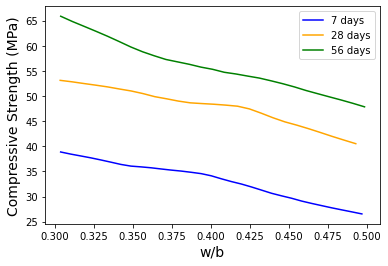

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_ANN_wb_7.csv')
df2 = pd.read_csv('pdp_ANN_wb_28.csv')
df3 = pd.read_csv('pdp_ANN_wb_56.csv')
odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['wb', 'fc']
df2.columns = ['wb', 'fc']
df3.columns = ['wb', 'fc']
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]
# Plot the results
plt.figure()
plt.plot(df1['wb'],df1['fc'], label='7 days',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['wb'], df2['fc'], label='28 days', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['wb'], df3['fc'], label='56 days', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')
plt.ylabel('Compressive Strength (MPa)',fontsize=14)
plt.xlabel('w/b',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_wb_KINN.png', bbox_inches='tight',dpi=600)

📈 XGBoost PDP 图表已保存为 PDP_wb_XGB.png


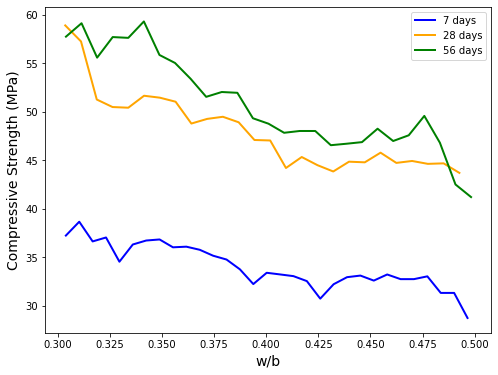

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载三个时间节点的 XGBoost PDP 结果文件
# 注意：请确保你已经运行了 7, 28, 56 三个版本的 XGB 代码并生成了对应的 CSV
df1 = pd.read_csv('pdp_XGB_wb_7.csv')
df2 = pd.read_csv('pdp_XGB_wb_28.csv')
df3 = pd.read_csv('pdp_XGB_wb_56.csv')

# 加载原始数据（用于参考，如果需要取消散点图注释的话）
odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')

# 统一列名
df1.columns = ['wb', 'fc']
df2.columns = ['wb', 'fc']
df3.columns = ['wb', 'fc']

# 筛选特定的 w/b 范围 (0.3 到 0.5)
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]

# 2. 开始绘图
plt.figure(figsize=(8, 6))

# 绘制 7天、28天、56天 的趋势线
plt.plot(df1['wb'], df1['fc'], label='7 days', color='blue', linewidth=2)
plt.plot(df2['wb'], df2['fc'], label='28 days', color='orange', linewidth=2)
plt.plot(df3['wb'], df3['fc'], label='56 days', color='green', linewidth=2)

# 如果想对比原始实验点，可以取消下面的注释
# plt.scatter(odf1['w/b'], odf1['fc (MPa)'], alpha=0.3, color='blue', s=10)
# plt.scatter(odf2['w/b'], odf2['fc (MPa)'], alpha=0.3, color='orange', s=10)
# plt.scatter(odf3['w/b'], odf3['fc (MPa)'], alpha=0.3, color='green', s=10)

# 设置轴标签
plt.ylabel('Compressive Strength (MPa)', fontsize=14)
plt.xlabel('w/b', fontsize=14)

# 图例与网格
plt.legend(frameon=True)
# plt.grid(True, linestyle='--', alpha=0.6)

# 3. 保存图片
# 文件名改为 PDP_wb_XGB.png
plt.savefig('PDP_wb_XGB.png', bbox_inches='tight', dpi=600)
print("📈 XGBoost PDP 图表已保存为 PDP_wb_XGB.png")

plt.show()

📈 绘图完成！图片已保存为 PDP_wb_RF.png


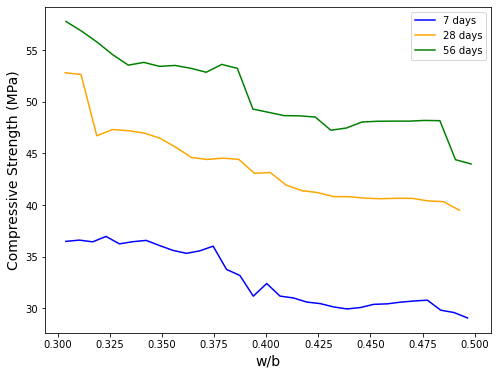

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 RF 生成的 CSV
df1 = pd.read_csv('pdp_RF_wb_7.csv')
df2 = pd.read_csv('pdp_RF_wb_28.csv')
df3 = pd.read_csv('pdp_RF_wb_56.csv')

# 筛选展示范围
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]

plt.figure(figsize=(8, 6))

# 绘图
plt.plot(df1['wb'], df1['fc'], label='7 days', color='blue')
plt.plot(df2['wb'], df2['fc'], label='28 days', color='orange')
plt.plot(df3['wb'], df3['fc'], label='56 days', color='green')

plt.ylabel('Compressive Strength (MPa)', fontsize=14)
plt.xlabel('w/b', fontsize=14)
# plt.title('RF Partial Dependence Plot', fontsize=12)

plt.legend()
# plt.grid(True, alpha=0.3)

# 保存为 RF 命名的图片
plt.savefig('PDP_wb_RF.png', bbox_inches='tight', dpi=600)
print("📈 绘图完成！图片已保存为 PDP_wb_RF.png")
plt.show()

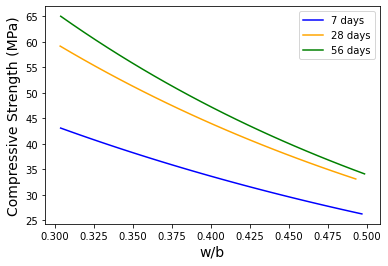

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_EE_wb_7_all.csv')
df2 = pd.read_csv('pdp_EE_wb_28_all.csv')
df3 = pd.read_csv('pdp_EE_wb_56_all.csv')
odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['wb', 'fc']
df2.columns = ['wb', 'fc']
df3.columns = ['wb', 'fc']
df1 = df1[(df1['wb'] >= 0.3) & (df1['wb'] <= 0.5)]
df2 = df2[(df2['wb'] >= 0.3) & (df2['wb'] <= 0.5)]
df3 = df3[(df3['wb'] >= 0.3) & (df3['wb'] <= 0.5)]
# Plot the results
plt.figure()
plt.plot(df1['wb'],df1['fc'], label='7 days',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['wb'], df2['fc'], label='28 days', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['wb'], df3['fc'], label='56 days', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')
plt.ylabel('Compressive Strength (MPa)',fontsize=14)
plt.xlabel('w/b',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_wb_EE_all.png', bbox_inches='tight',dpi=600)

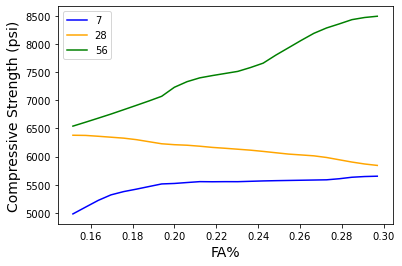

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_FA%.csv')
df2 = pd.read_csv('pdp_KINN_28_FA%.csv')
df3 = pd.read_csv('pdp_KINN_56_FA%.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['FA', 'fc']
df2.columns = ['FA', 'fc']
df3.columns = ['FA', 'fc']
df1 = df1[(df1['FA'] >= 0.15) & (df1['FA'] <= 0.3)]
df2 = df2[(df2['FA'] >= 0.15) & (df2['FA'] <= 0.3)]
df3 = df3[(df3['FA'] >= 0.15) & (df3['FA'] <= 0.3)]

# Plot the results
plt.figure()
plt.plot(df1['FA'],df1['fc']*145.0377, label='7',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['FA'], df2['fc']*145.0377, label='28', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['FA'], df3['fc']*145.0377, label='56', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (psi)',fontsize=14)
plt.xlabel('FA%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_FA_KINN.png', bbox_inches='tight',dpi=600)



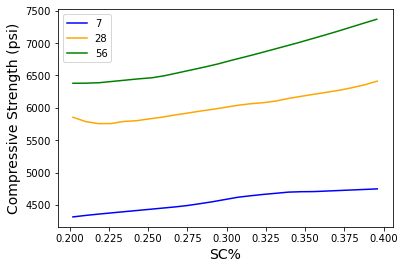

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_SS%.csv')
df2 = pd.read_csv('pdp_KINN_28_SS%.csv')
df3 = pd.read_csv('pdp_KINN_56_SS%.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SS', 'fc']
df2.columns = ['SS', 'fc']
df3.columns = ['SS', 'fc']
df1 = df1[(df1['SS'] >= 0.2) & (df1['SS'] <= 0.4)]
df2 = df2[(df2['SS'] >= 0.2) & (df2['SS'] <= 0.4)]
df3 = df3[(df3['SS'] >= 0.2) & (df3['SS'] <= 0.4)]

# Plot the results
plt.figure()
plt.plot(df1['SS'],df1['fc']*145.0377, label='7',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SS'], df2['fc']*145.0377, label='28', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SS'], df3['fc']*145.0377, label='56', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (psi)',fontsize=14)
plt.xlabel('SC%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_SS_KINN.png',bbox_inches='tight', dpi=600)



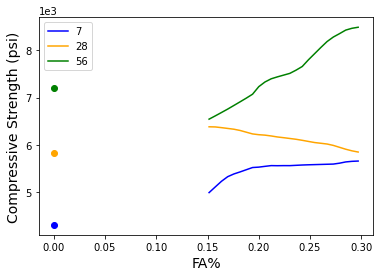

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_FA%.csv')
df2 = pd.read_csv('pdp_KINN_28_FA%.csv')
df3 = pd.read_csv('pdp_KINN_56_FA%.csv')

df1.columns = ['FA', 'fc']
df2.columns = ['FA', 'fc']
df3.columns = ['FA', 'fc']

# Create copies of the original dataframes before filtering
df1_filtered = df1[(df1['FA'] >= 0.15) & (df1['FA'] <= 0.3)]
df2_filtered = df2[(df2['FA'] >= 0.15) & (df2['FA'] <= 0.3)]
df3_filtered = df3[(df3['FA'] >= 0.15) & (df3['FA'] <= 0.3)]

# Plot the results using the filtered data
plt.figure()
plt.plot(df1_filtered['FA'], df1_filtered['fc'] * 145.0377, label='7', color='blue')
plt.plot(df2_filtered['FA'], df2_filtered['fc'] * 145.0377, label='28', color='orange')
plt.plot(df3_filtered['FA'], df3_filtered['fc'] * 145.0377, label='56', color='green')

# Add the point for FA = 0 for each dataset from the original (unfiltered) data
plt.scatter(0, df1[df1['FA'] == 0]['fc'].values[0] * 145.0377, color='blue', zorder=5)
plt.scatter(0, df2[df2['FA'] == 0]['fc'].values[0] * 145.0377, color='orange', zorder=5)
plt.scatter(0, df3[df3['FA'] == 0]['fc'].values[0] * 145.0377, color='green', zorder=5)

plt.ylabel('Compressive Strength (psi)', fontsize=14)
plt.xlabel('FA%', fontsize=14)

plt.legend()
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_FA_KINN_add_0.png', dpi=600)


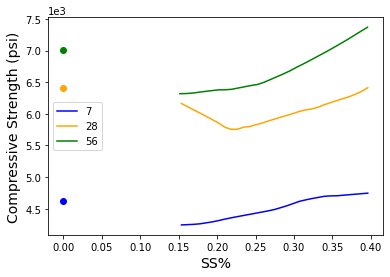

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_SS%.csv')
df2 = pd.read_csv('pdp_KINN_28_SS%.csv')
df3 = pd.read_csv('pdp_KINN_56_SS%.csv')

df1.columns = ['SS', 'fc']
df2.columns = ['SS', 'fc']
df3.columns = ['SS', 'fc']

# Create copies of the original dataframes before filtering
df1_filtered = df1[(df1['SS'] >= 0.15) & (df1['SS'] <= 0.4)]
df2_filtered = df2[(df2['SS'] >= 0.15) & (df2['SS'] <= 0.4)]
df3_filtered = df3[(df3['SS'] >= 0.15) & (df3['SS'] <= 0.4)]

# Plot the results using the filtered data
plt.figure()
plt.plot(df1_filtered['SS'], df1_filtered['fc'] * 145.0377, label='7', color='blue')
plt.plot(df2_filtered['SS'], df2_filtered['fc'] * 145.0377, label='28', color='orange')
plt.plot(df3_filtered['SS'], df3_filtered['fc'] * 145.0377, label='56', color='green')

# Add the point for SS = 0 for each dataset from the original (unfiltered) data
plt.scatter(0, df1[df1['SS'] == 0]['fc'].values[0] * 145.0377, color='blue', zorder=5)
plt.scatter(0, df2[df2['SS'] == 0]['fc'].values[0] * 145.0377, color='orange', zorder=5)
plt.scatter(0, df3[df3['SS'] == 0]['fc'].values[0] * 145.0377, color='green', zorder=5)

plt.ylabel('Compressive Strength (psi)', fontsize=14)
plt.xlabel('SS%', fontsize=14)

plt.legend()
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_SS_KINN_add_0.png', dpi=600)


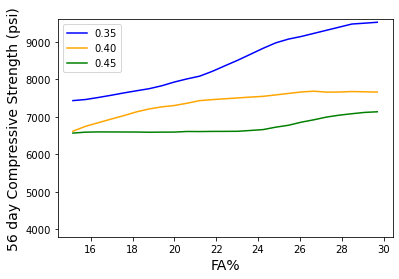

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_56_FA%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_56_FA%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_56_FA%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['FA', 'fc']
df2.columns = ['FA', 'fc']
df3.columns = ['FA', 'fc']

df1 = df1[(df1['FA'] >= 0.15) & (df1['FA'] <= 0.3)]
df2 = df2[(df2['FA'] >= 0.15) & (df2['FA'] <= 0.3)]
df3 = df3[(df3['FA'] >= 0.15) & (df3['FA'] <= 0.3)]


df1['FA'] = df1['FA'] * 100
df2['FA'] = df2['FA'] * 100
df3['FA'] = df3['FA'] * 100
# Plot the results
plt.figure()
plt.plot(df1['FA'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['FA'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['FA'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('56 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('FA%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(3800,9600)

plt.savefig('PDP_FA_KINN_56day.png', bbox_inches='tight',dpi=600)



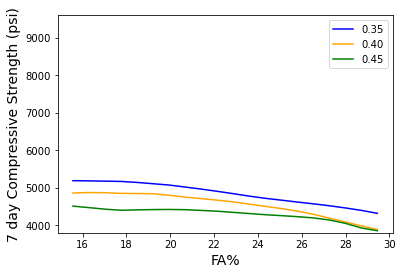

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_FA%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_7_FA%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_7_FA%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['FA', 'fc']
df2.columns = ['FA', 'fc']
df3.columns = ['FA', 'fc']
df1 = df1[(df1['FA'] >= 0.15) & (df1['FA'] <= 0.3)]
df2 = df2[(df2['FA'] >= 0.15) & (df2['FA'] <= 0.3)]
df3 = df3[(df3['FA'] >= 0.15) & (df3['FA'] <= 0.3)]
df1['FA'] = df1['FA'] * 100
df2['FA'] = df2['FA'] * 100
df3['FA'] = df3['FA'] * 100

# Plot the results
plt.figure()
plt.plot(df1['FA'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['FA'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['FA'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('7 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('FA%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(3800,9600)
plt.savefig('PDP_FA_KINN_7day.png', bbox_inches='tight',dpi=600)



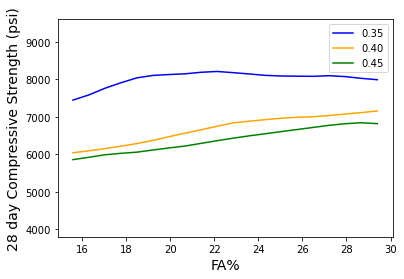

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_28_FA%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_28_FA%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_28_FA%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['FA', 'fc']
df2.columns = ['FA', 'fc']
df3.columns = ['FA', 'fc']
df1 = df1[(df1['FA'] >= 0.15) & (df1['FA'] <= 0.3)]
df2 = df2[(df2['FA'] >= 0.15) & (df2['FA'] <= 0.3)]
df3 = df3[(df3['FA'] >= 0.15) & (df3['FA'] <= 0.3)]
df1['FA'] = df1['FA'] * 100
df2['FA'] = df2['FA'] * 100
df3['FA'] = df3['FA'] * 100

# Plot the results
plt.figure()
plt.plot(df1['FA'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['FA'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['FA'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('28 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('FA%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(3800,9600)
plt.savefig('PDP_FA_KINN_28day.png', bbox_inches='tight',dpi=600)



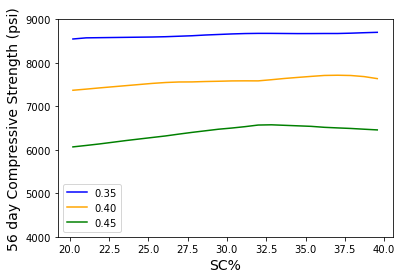

In [264]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_56_SS%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_56_SS%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_56_SS%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SS', 'fc']
df2.columns = ['SS', 'fc']
df3.columns = ['SS', 'fc']
df1 = df1[(df1['SS'] >= 0.2) & (df1['SS'] <= 0.4)]
df2 = df2[(df2['SS'] >= 0.2) & (df2['SS'] <= 0.4)]
df3 = df3[(df3['SS'] >= 0.2) & (df3['SS'] <= 0.4)]
df1['SS'] = df1['SS'] * 100
df2['SS'] = df2['SS'] * 100
df3['SS'] = df3['SS'] * 100

# Plot the results
plt.figure()
plt.plot(df1['SS'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SS'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SS'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('56 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('SC%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(4000,9000)
plt.savefig('PDP_SS_KINN_56day.png', bbox_inches='tight',dpi=600)



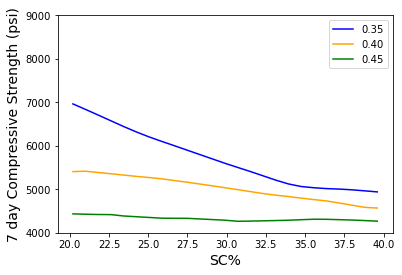

In [265]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_SS%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_7_SS%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_7_SS%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SS', 'fc']
df2.columns = ['SS', 'fc']
df3.columns = ['SS', 'fc']
df1 = df1[(df1['SS'] >= 0.2) & (df1['SS'] <= 0.4)]
df2 = df2[(df2['SS'] >= 0.2) & (df2['SS'] <= 0.4)]
df3 = df3[(df3['SS'] >= 0.2) & (df3['SS'] <= 0.4)]
df1['SS'] = df1['SS'] * 100
df2['SS'] = df2['SS'] * 100
df3['SS'] = df3['SS'] * 100
# Plot the results
plt.figure()
plt.plot(df1['SS'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SS'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SS'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('7 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('SC%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(4000,9000)
plt.savefig('PDP_SS_KINN_7day.png', bbox_inches='tight',dpi=600)



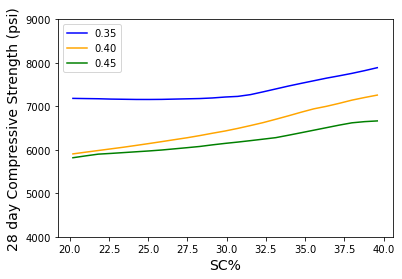

In [266]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_28_SS%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_28_SS%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_28_SS%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SS', 'fc']
df2.columns = ['SS', 'fc']
df3.columns = ['SS', 'fc']
df1 = df1[(df1['SS'] >= 0.2) & (df1['SS'] <= 0.4)]
df2 = df2[(df2['SS'] >= 0.2) & (df2['SS'] <= 0.4)]
df3 = df3[(df3['SS'] >= 0.2) & (df3['SS'] <= 0.4)]
df1['SS'] = df1['SS'] * 100
df2['SS'] = df2['SS'] * 100
df3['SS'] = df3['SS'] * 100
# Plot the results
plt.figure()
plt.plot(df1['SS'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SS'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SS'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('28 day Compressive Strength (psi)',fontsize=14)
plt.xlabel('SC%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(4000,9000)
plt.savefig('PDP_SS_KINN_28day.png', bbox_inches='tight',dpi=600)



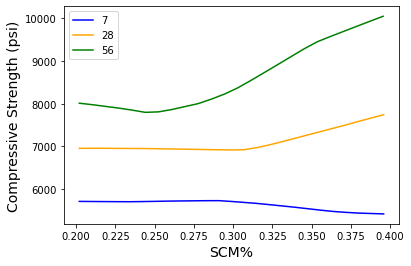

In [225]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_SCM%.csv')
df2 = pd.read_csv('pdp_KINN_28_SCM%.csv')
df3 = pd.read_csv('pdp_KINN_56_SCM%.csv')

df1.columns = ['SCM', 'fc']
df2.columns = ['SCM', 'fc']
df3.columns = ['SCM', 'fc']

# Create copies of the original dataframes before filtering
df1_filtered = df1[(df1['SCM'] >= 0.2) & (df1['SCM'] <= 0.4)]
df2_filtered = df2[(df2['SCM'] >= 0.2) & (df2['SCM'] <= 0.4)]
df3_filtered = df3[(df3['SCM'] >= 0.2) & (df3['SCM'] <= 0.4)]

# Plot the results using the filtered data
plt.figure()
plt.plot(df1_filtered['SCM'], df1_filtered['fc'] * 145.0377, label='7', color='blue')
plt.plot(df2_filtered['SCM'], df2_filtered['fc'] * 145.0377, label='28', color='orange')
plt.plot(df3_filtered['SCM'], df3_filtered['fc'] * 145.0377, label='56', color='green')

# Add the point for FA = 0 for each dataset from the original (unfiltered) data
# plt.scatter(0, df1[df1['SCM'] == 0]['fc'].values[0] * 145.0377, color='blue', zorder=5)
# plt.scatter(0, df2[df2['SCM'] == 0]['fc'].values[0] * 145.0377, color='orange', zorder=5)
# plt.scatter(0, df3[df3['SCM'] == 0]['fc'].values[0] * 145.0377, color='green', zorder=5)

plt.ylabel('Compressive Strength (psi)', fontsize=14)
plt.xlabel('SCM%', fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.savefig('PDP_scm%_KINN.png', bbox_inches='tight', dpi=600)


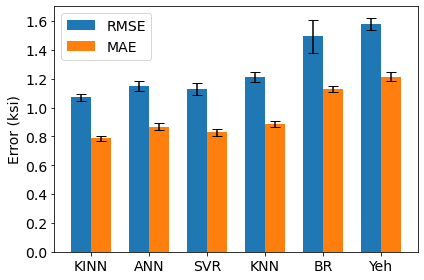

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Prepare base model data (already scaled back to psi)
data = {
    "Model": ["KINN", "ANN", "SVR", "KNN", "BR"],
    "RMSE_avg_psi": [1069.98, 1150.73, 1130.55, 1211.30, 1493.93],
    "RMSE_std_psi": [22.21, 34.32, 40.38, 32.30, 113.05],
    "MAE_avg_psi": [787.34, 868.10, 827.72, 888.29, 1130.55],
    "MAE_std_psi": [16.15, 22.21, 24.23, 20.19, 20.19]
}

df = pd.DataFrame(data)

# Step 2: Add Yeh’s equation
yeh_row = {
    "Model": "Yeh",
    "RMSE_avg_psi": 1579.3,
    "RMSE_std_psi": 41.1,
    "MAE_avg_psi": 1212.7,
    "MAE_std_psi": 30.6,
}
df = pd.concat([df, pd.DataFrame([yeh_row])], ignore_index=True)

# Step 3: Plotting

x = np.arange(len(df["Model"]))  # Label locations
width = 0.35  # Width of bars

fig, ax = plt.subplots()

# RMSE bars
ax.bar(x - width/2, df["RMSE_avg_psi"]/1000, width,
       yerr=df["RMSE_std_psi"]/1000, label='RMSE', capsize=5)

# MAE bars
ax.bar(x + width/2, df["MAE_avg_psi"]/1000, width,
       yerr=df["MAE_std_psi"]/1000, label='MAE', capsize=5)

# Labels and title
ax.set_ylabel('Error (ksi)', fontsize=14)
# ax.set_title('Model Comparison of MAE and RMSE (in psi)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], fontsize=14)
ax.legend(fontsize=14)
plt.yticks(fontsize=14)
# ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
# plt.show()
# ax.set_yscale('log')
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.savefig('error bar.png', bbox_inches='tight', dpi=600)

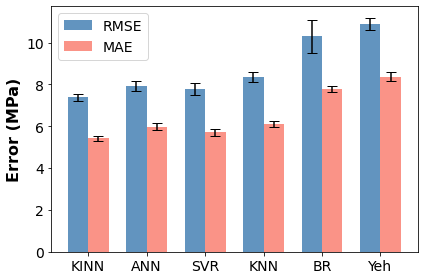

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 换算常数: 1 psi = 0.00689476 MPa
psi_to_mpa = 0.00689476

# Step 1: 准备原始数据 (psi 单位)
data = {
    "Model": ["KINN", "ANN", "SVR", "KNN", "BR"],
    "RMSE_avg_psi": [1069.98, 1150.73, 1130.55, 1211.30, 1493.93],
    "RMSE_std_psi": [22.21, 34.32, 40.38, 32.30, 113.05],
    "MAE_avg_psi": [787.34, 868.10, 827.72, 888.29, 1130.55],
    "MAE_std_psi": [16.15, 22.21, 24.23, 20.19, 20.19]
}

df = pd.DataFrame(data)

# Step 2: 添加 Yeh's 方程数据
yeh_row = {
    "Model": "Yeh",
    "RMSE_avg_psi": 1579.3,
    "RMSE_std_psi": 41.1,
    "MAE_avg_psi": 1212.7,
    "MAE_std_psi": 30.6,
}
df = pd.concat([df, pd.DataFrame([yeh_row])], ignore_index=True)

# Step 3: 绘图

x = np.arange(len(df["Model"]))  # 标签位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots()

# RMSE 柱状图 (乘以换算系数)
ax.bar(x - width/2, df["RMSE_avg_psi"] * psi_to_mpa, width,
       yerr=df["RMSE_std_psi"] * psi_to_mpa, label='RMSE', capsize=5, color='steelblue', alpha=0.85)

# MAE 柱状图 (乘以换算系数)
ax.bar(x + width/2, df["MAE_avg_psi"] * psi_to_mpa, width,
       yerr=df["MAE_std_psi"] * psi_to_mpa, label='MAE', capsize=5, color='salmon', alpha=0.85)

# 标签与设置
ax.set_ylabel('Error (MPa)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], fontsize=14)
ax.legend(fontsize=14)
plt.yticks(fontsize=14)

# 添加轻微的网格线增加可读性
# ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# 保存高质量图片
plt.savefig('error_bar_mpa.png', bbox_inches='tight', dpi=600)
plt.show()

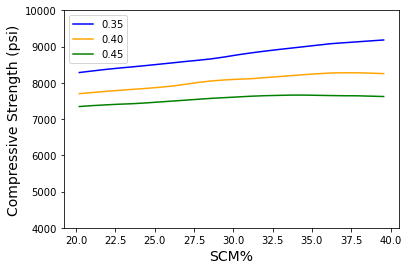

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_56_SCM%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_56_SCM%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_56_SCM%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SCM', 'fc']
df2.columns = ['SCM', 'fc']
df3.columns = ['SCM', 'fc']
df1 = df1[(df1['SCM'] >= 0.2) & (df1['SCM'] <= 0.4)]
df2 = df2[(df2['SCM'] >= 0.2) & (df2['SCM'] <= 0.4)]
df3 = df3[(df3['SCM'] >= 0.2) & (df3['SCM'] <= 0.4)]
df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100
# Plot the results
plt.figure()
plt.plot(df1['SCM'],df1['fc']*145.0377, label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SCM'], df2['fc']*145.0377, label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SCM'], df3['fc']*145.0377, label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (psi)',fontsize=14)
plt.xlabel('SCM%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(4000,10000)
plt.savefig('PDP_SCM_KINN_56day.png', bbox_inches='tight',dpi=600)



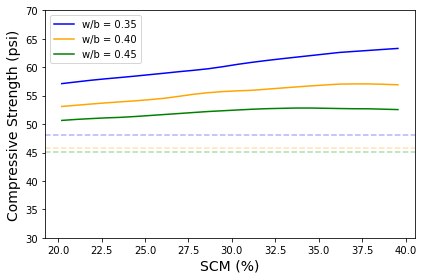

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read each CSV into a "full" DataFrame to grab the SCM = 0 row
df1_full = pd.read_csv('pdp_KINN_56_SCM%_0.35.csv')
df2_full = pd.read_csv('pdp_KINN_56_SCM%_0.4.csv')
df3_full = pd.read_csv('pdp_KINN_56_SCM%_0.45.csv')

# 2) Rename columns so we can refer to 'SCM' and 'fc'
df1_full.columns = ['SCM', 'fc']
df2_full.columns = ['SCM', 'fc']
df3_full.columns = ['SCM', 'fc']

# 3) Extract the baseline fc at SCM = 0 (in MPa), then convert to psi
fc1_baseline = df1_full.loc[df1_full['SCM'] == 0, 'fc'].values[0] 
fc2_baseline = df2_full.loc[df2_full['SCM'] == 0, 'fc'].values[0] 
fc3_baseline = df3_full.loc[df3_full['SCM'] == 0, 'fc'].values[0] 

# 4) Filter each DataFrame to 0.2 ≤ SCM ≤ 0.4, then convert SCM fraction → percent
df1 = df1_full[(df1_full['SCM'] >= 0.2) & (df1_full['SCM'] <= 0.4)].copy()
df2 = df2_full[(df2_full['SCM'] >= 0.2) & (df2_full['SCM'] <= 0.4)].copy()
df3 = df3_full[(df3_full['SCM'] >= 0.2) & (df3_full['SCM'] <= 0.4)].copy()

df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100

# 5) Plot the three SCM‐vs‐fc curves
plt.figure(figsize=(6, 4))

plt.plot(df1['SCM'], df1['fc'], label='w/b = 0.35', color='blue')
plt.plot(df2['SCM'], df2['fc'], label='w/b = 0.40', color='orange')
plt.plot(df3['SCM'], df3['fc'], label='w/b = 0.45', color='green')

# 6) Add horizontal dashed lines at the SCM = 0 baseline values
#    (same colors but with alpha=0.3 and linestyle='--')
plt.axhline(y=fc1_baseline-2, color='blue', linestyle='--', alpha=0.3)
plt.axhline(y=fc2_baseline, color='orange', linestyle='--', alpha=0.3)
plt.axhline(y=fc3_baseline, color='green', linestyle='--', alpha=0.3)

# 7) Labels, legend, and axis limits
plt.ylabel('Compressive Strength (psi)', fontsize=14)
plt.xlabel('SCM (%)', fontsize=14)
plt.ylim(30, 70)
plt.legend()

# 8) Save the figure
plt.tight_layout()
plt.savefig('PDP_SCM_KINN_56day_with_baseline.png', bbox_inches='tight', dpi=600)


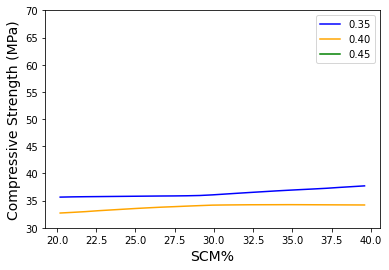

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_7_SCM%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_7_SCM%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_7_SCM%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SCM', 'fc']
df2.columns = ['SCM', 'fc']
df3.columns = ['SCM', 'fc']
df1 = df1[(df1['SCM'] >= 0.2) & (df1['SCM'] <= 0.4)]
df2 = df2[(df2['SCM'] >= 0.2) & (df2['SCM'] <= 0.4)]
df3 = df3[(df3['SCM'] >= 0.2) & (df3['SCM'] <= 0.4)]
df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100
# Plot the results
plt.figure()
plt.plot(df1['SCM'],df1['fc'], label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)']*145.0377, alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SCM'], df2['fc'], label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)']*145.0377, alpha = 0.4,color='#FFCA64')
plt.plot(df3['SCM'], df3['fc'], label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)']*145.0377, alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (MPa)',fontsize=14)
plt.xlabel('SCM%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(30,70)
plt.savefig('PDP_SCM_KINN_7day.png', bbox_inches='tight',dpi=600)



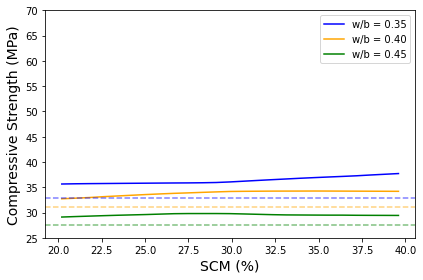

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read each CSV into a "full" DataFrame to grab the SCM=0 row
df1_full = pd.read_csv('pdp_KINN_7_SCM%_0.35.csv')
df2_full = pd.read_csv('pdp_KINN_7_SCM%_0.4.csv')
df3_full = pd.read_csv('pdp_KINN_7_SCM%_0.45.csv')

# Rename columns so we can refer to 'SCM' and 'fc'
df1_full.columns = ['SCM', 'fc']
df2_full.columns = ['SCM', 'fc']
df3_full.columns = ['SCM', 'fc']

# 2) Extract the baseline fc at SCM = 0 (in MPa), then convert to psi
#    We assume there is exactly one row where SCM == 0 in each CSV
fc1_baseline = df1_full.loc[df1_full['SCM'] == 0, 'fc'].values[0] 
fc2_baseline = df2_full.loc[df2_full['SCM'] == 0, 'fc'].values[0] 
fc3_baseline = df3_full.loc[df3_full['SCM'] == 0, 'fc'].values[0] 

# 3) Now create filtered DataFrames for plotting (SCM between 0.2 and 0.4),
#    and convert SCM to percent
df1 = df1_full.copy()
df2 = df2_full.copy()
df3 = df3_full.copy()

# Filter to 0.2 ≤ SCM ≤ 0.4
df1 = df1[(df1['SCM'] >= 0.2) & (df1['SCM'] <= 0.4)].copy()
df2 = df2[(df2['SCM'] >= 0.2) & (df2['SCM'] <= 0.4)].copy()
df3 = df3[(df3['SCM'] >= 0.2) & (df3['SCM'] <= 0.4)].copy()

# Convert SCM fraction → percent
df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100

# 4) Plot the three curves
plt.figure(figsize=(6, 4))

plt.plot(df1['SCM'], df1['fc'] , label='w/b = 0.35', color='blue')
plt.plot(df2['SCM'], df2['fc'] , label='w/b = 0.40', color='orange')
plt.plot(df3['SCM'], df3['fc'] , label='w/b = 0.45', color='green')

# 5) Add horizontal dashed lines at the baseline (SCM = 0) fc values
#    Use the same colors but with alpha=0.3 and linestyle='--'
plt.axhline(y=fc1_baseline, color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=fc2_baseline, color='orange', linestyle='--', alpha=0.5)
plt.axhline(y=fc3_baseline, color='green', linestyle='--', alpha=0.5)

# 6) Labels, legend, and axis limits
plt.ylabel('Compressive Strength (MPa)', fontsize=14)
plt.xlabel('SCM (%)', fontsize=14)
plt.ylim(25, 70)
plt.legend()

# 7) Save figure
plt.tight_layout()
plt.savefig('PDP_SCM_KINN_7day_with_baseline.png', bbox_inches='tight', dpi=600)


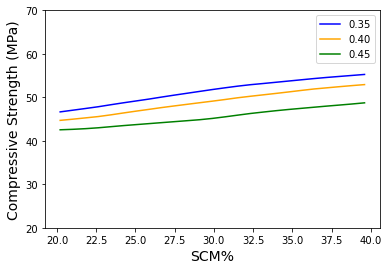

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the three CSV files
df1 = pd.read_csv('pdp_KINN_28_SCM%_0.35.csv')
df2 = pd.read_csv('pdp_KINN_28_SCM%_0.4.csv')
df3 = pd.read_csv('pdp_KINN_28_SCM%_0.45.csv')
# odf1 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='7')
# odf2 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='28')
# odf3 = pd.read_excel(r'updated_fc_predictions_with_fc_hat.xlsx', sheet_name='56')
df1.columns = ['SCM', 'fc']
df2.columns = ['SCM', 'fc']
df3.columns = ['SCM', 'fc']
df1 = df1[(df1['SCM'] >= 0.2) & (df1['SCM'] <= 0.4)]
df2 = df2[(df2['SCM'] >= 0.2) & (df2['SCM'] <= 0.4)]
df3 = df3[(df3['SCM'] >= 0.2) & (df3['SCM'] <= 0.4)]
df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100
# Plot the results
plt.figure()
plt.plot(df1['SCM'],df1['fc'], label='0.35',color = 'blue')
# plt.scatter(odf1['w/b'],odf1['fc (MPa)'], alpha = 0.6,color = '#63b2ee')
plt.plot(df2['SCM'], df2['fc'], label='0.40', color = 'orange')
# plt.scatter(odf2['w/b'],odf2['fc (MPa)'], alpha = 0.4,color='#FFCA64')
plt.plot(df3['SCM'], df3['fc'], label='0.45', color = 'green')
# plt.scatter(odf3['w/b'],odf3['fc (MPa)'], alpha = 0.3,color='#90EE90')

plt.ylabel('Compressive Strength (MPa)',fontsize=14)
plt.xlabel('SCM%',fontsize=14)

plt.legend()
# ax = plt.gca()
# ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(20,70)
plt.savefig('PDP_SCM_KINN_28day.png', bbox_inches='tight',dpi=600)



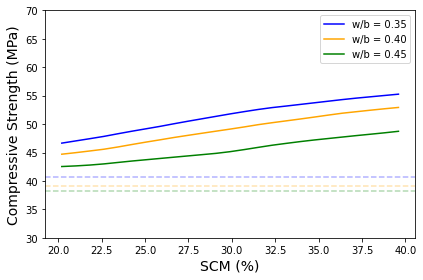

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read each CSV into a "full" DataFrame to grab the SCM=0 row
df1_full = pd.read_csv('pdp_KINN_28_SCM%_0.35.csv')
df2_full = pd.read_csv('pdp_KINN_28_SCM%_0.4.csv')
df3_full = pd.read_csv('pdp_KINN_28_SCM%_0.45.csv')

# 2) Rename columns so we can refer to 'SCM' and 'fc'
df1_full.columns = ['SCM', 'fc']
df2_full.columns = ['SCM', 'fc']
df3_full.columns = ['SCM', 'fc']

# 3) Extract the baseline fc at SCM = 0 (in MPa), then convert to psi
fc1_baseline = df1_full.loc[df1_full['SCM'] == 0, 'fc'].values[0] 
fc2_baseline = df2_full.loc[df2_full['SCM'] == 0, 'fc'].values[0]
fc3_baseline = df3_full.loc[df3_full['SCM'] == 0, 'fc'].values[0]

# 4) Now create filtered DataFrames for plotting (SCM between 0.2 and 0.4),
#    and convert SCM to percent
df1 = df1_full[(df1_full['SCM'] >= 0.2) & (df1_full['SCM'] <= 0.4)].copy()
df2 = df2_full[(df2_full['SCM'] >= 0.2) & (df2_full['SCM'] <= 0.4)].copy()
df3 = df3_full[(df3_full['SCM'] >= 0.2) & (df3_full['SCM'] <= 0.4)].copy()

df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100

# 5) Plot the three curves
plt.figure(figsize=(6, 4))

plt.plot(df1['SCM'], df1['fc'], label='w/b = 0.35', color='blue')
plt.plot(df2['SCM'], df2['fc'], label='w/b = 0.40', color='orange')
plt.plot(df3['SCM'], df3['fc'], label='w/b = 0.45', color='green')

# 6) Add horizontal dashed lines at the baseline (SCM = 0) fc values
#    Use the same colors but with alpha=0.3 and linestyle='--'
plt.axhline(y=fc1_baseline, color='blue', linestyle='--', alpha=0.3)
plt.axhline(y=fc2_baseline-2, color='orange', linestyle='--', alpha=0.3)
plt.axhline(y=fc3_baseline-2, color='green', linestyle='--', alpha=0.3)

# 7) Labels, legend, and axis limits
plt.ylabel('Compressive Strength (MPa)', fontsize=14)
plt.xlabel('SCM (%)', fontsize=14)
plt.ylim(30, 70)
plt.legend()

# 8) Save figure
plt.tight_layout()
plt.savefig('PDP_SCM_KINN_28day_with_baseline.png', bbox_inches='tight', dpi=600)


Baseline (w/b = 0.35): 40.66 MPa
Baseline (w/b = 0.40): 39.17 MPa (adjusted by -2)
Baseline (w/b = 0.45): 38.20 MPa (adjusted by -2)


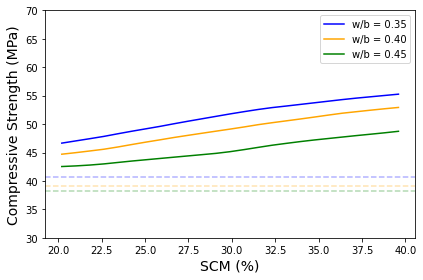

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read each CSV into a "full" DataFrame to grab the SCM=0 row
df1_full = pd.read_csv('pdp_KINN_28_SCM%_0.35.csv')
df2_full = pd.read_csv('pdp_KINN_28_SCM%_0.4.csv')
df3_full = pd.read_csv('pdp_KINN_28_SCM%_0.45.csv')

# 2) Rename columns so we can refer to 'SCM' and 'fc'
df1_full.columns = ['SCM', 'fc']
df2_full.columns = ['SCM', 'fc']
df3_full.columns = ['SCM', 'fc']

# 3) Extract the baseline fc at SCM = 0 (in MPa)
fc1_baseline = df1_full.loc[df1_full['SCM'] == 0, 'fc'].values[0] 
fc2_baseline = df2_full.loc[df2_full['SCM'] == 0, 'fc'].values[0]
fc3_baseline = df3_full.loc[df3_full['SCM'] == 0, 'fc'].values[0]

# --- 新增：打印虚线的具体数值 ---
print(f"Baseline (w/b = 0.35): {fc1_baseline:.2f} MPa")
print(f"Baseline (w/b = 0.40): {fc2_baseline - 2:.2f} MPa (adjusted by -2)")
print(f"Baseline (w/b = 0.45): {fc3_baseline - 2:.2f} MPa (adjusted by -2)")
# ------------------------------

# 4) Now create filtered DataFrames for plotting (SCM between 0.2 and 0.4),
#    and convert SCM to percent
df1 = df1_full[(df1_full['SCM'] >= 0.2) & (df1_full['SCM'] <= 0.4)].copy()
df2 = df2_full[(df2_full['SCM'] >= 0.2) & (df2_full['SCM'] <= 0.4)].copy()
df3 = df3_full[(df3_full['SCM'] >= 0.2) & (df3_full['SCM'] <= 0.4)].copy()

df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100

# 5) Plot the three curves
plt.figure(figsize=(6, 4))

plt.plot(df1['SCM'], df1['fc'], label='w/b = 0.35', color='blue')
plt.plot(df2['SCM'], df2['fc'], label='w/b = 0.40', color='orange')
plt.plot(df3['SCM'], df3['fc'], label='w/b = 0.45', color='green')

# 6) Add horizontal dashed lines
plt.axhline(y=fc1_baseline, color='blue', linestyle='--', alpha=0.3)
plt.axhline(y=fc2_baseline-2, color='orange', linestyle='--', alpha=0.3)
plt.axhline(y=fc3_baseline-2, color='green', linestyle='--', alpha=0.3)

# 7) Labels, legend, and axis limits
plt.ylabel('Compressive Strength (MPa)', fontsize=14)
plt.xlabel('SCM (%)', fontsize=14)
plt.ylim(30, 70)
plt.legend()

# 8) Save figure
plt.tight_layout()
plt.savefig('PDP_SCM_KINN_28day_with_baseline.png', bbox_inches='tight', dpi=600)

Baseline (w/b = 0.35): 48.01 (adjusted by -2)
Baseline (w/b = 0.40): 45.72
Baseline (w/b = 0.45): 45.18


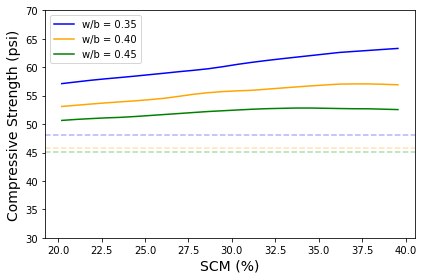

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read each CSV into a "full" DataFrame to grab the SCM = 0 row
df1_full = pd.read_csv('pdp_KINN_56_SCM%_0.35.csv')
df2_full = pd.read_csv('pdp_KINN_56_SCM%_0.4.csv')
df3_full = pd.read_csv('pdp_KINN_56_SCM%_0.45.csv')

# 2) Rename columns so we can refer to 'SCM' and 'fc'
df1_full.columns = ['SCM', 'fc']
df2_full.columns = ['SCM', 'fc']
df3_full.columns = ['SCM', 'fc']

# 3) Extract the baseline fc at SCM = 0
fc1_baseline = df1_full.loc[df1_full['SCM'] == 0, 'fc'].values[0] 
fc2_baseline = df2_full.loc[df2_full['SCM'] == 0, 'fc'].values[0] 
fc3_baseline = df3_full.loc[df3_full['SCM'] == 0, 'fc'].values[0] 

# --- 新增：打印虚线的具体数值 ---
print(f"Baseline (w/b = 0.35): {fc1_baseline - 2:.2f} (adjusted by -2)")
print(f"Baseline (w/b = 0.40): {fc2_baseline:.2f}")
print(f"Baseline (w/b = 0.45): {fc3_baseline:.2f}")
# ------------------------------

# 4) Filter each DataFrame to 0.2 ≤ SCM ≤ 0.4, then convert SCM fraction → percent
df1 = df1_full[(df1_full['SCM'] >= 0.2) & (df1_full['SCM'] <= 0.4)].copy()
df2 = df2_full[(df2_full['SCM'] >= 0.2) & (df2_full['SCM'] <= 0.4)].copy()
df3 = df3_full[(df3_full['SCM'] >= 0.2) & (df3_full['SCM'] <= 0.4)].copy()

df1['SCM'] = df1['SCM'] * 100
df2['SCM'] = df2['SCM'] * 100
df3['SCM'] = df3['SCM'] * 100

# 5) Plot the three SCM‐vs‐fc curves
plt.figure(figsize=(6, 4))

plt.plot(df1['SCM'], df1['fc'], label='w/b = 0.35', color='blue')
plt.plot(df2['SCM'], df2['fc'], label='w/b = 0.40', color='orange')
plt.plot(df3['SCM'], df3['fc'], label='w/b = 0.45', color='green')

# 6) Add horizontal dashed lines at the SCM = 0 baseline values
plt.axhline(y=fc1_baseline-2, color='blue', linestyle='--', alpha=0.3)
plt.axhline(y=fc2_baseline, color='orange', linestyle='--', alpha=0.3)
plt.axhline(y=fc3_baseline, color='green', linestyle='--', alpha=0.3)

# 7) Labels, legend, and axis limits
plt.ylabel('Compressive Strength (psi)', fontsize=14)
plt.xlabel('SCM (%)', fontsize=14)
plt.ylim(30, 70)
plt.legend()

# 8) Save the figure
plt.tight_layout()
plt.savefig('PDP_SCM_KINN_56day_with_baseline.png', bbox_inches='tight', dpi=600)